In [1]:
import numpy as np
import pickle
import gzip

from qiskit.quantum_info import SparsePauliOp

from matplotlib import pyplot as plt

from qphaset.phases import gstates_to_rdms_matrix, phases_vfield, gstates_to_rdms_matrix_qs_mps
from qphaset.plotting import plot_grad_g_angle_stream
from qphaset.linalg import schmidt_decomp_half, schmidt_decomp_2q_angles

In [2]:
gamma = None

## General solution (beta) for the order parameter discovery.
This is the (beta!) implementation of the most general form of the order parameter discovery (in the paper, this is the second problem in the section deicated to the order parameter discovery, soon more details will be expanded).

In [3]:
model_name = "Cluster"
l = 12
n = 20
params = np.linspace(0.1, 1.5, n), np.linspace(1.5, 0.1, n) # upside-down

model_name = "ANNNI"
l = 12
n = 30
params = np.linspace(0.5, 2.1, n), np.linspace(1.6, 0.01, n) # upside-down

params = map(lambda m: m.flatten(), np.meshgrid(*params, indexing='xy'))
params = tuple(params)
params = np.stack(params).T
params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

theta = 0
#gamma = 50
obs_ev_idx = 2
v0_first_schmidt_vec = False

device = 'pc'
# device = 'ngt'

if device == 'pc':
    device_path = "D:/code"
elif device == 'ngt':
    device_path = "/eos/user/f/fdimarca"

# dmrg params
chi = 100 # bond dimension
c1 = 1e-3 # eps symm. break.
if model_name == 'ANNNI':
    path_to_tensor = f"{device_path}/projects/2_ANNNI/results/data"
    path_to_figures = f"{device_path}/projects/2_ANNNI/figures"
    axis_name = ('k', 'h')

elif model_name == 'Cluster':
    path_to_tensor = f"{device_path}/projects/3_CLUSTER/results/data"
    path_to_figures = f"{device_path}/projects/3_CLUSTER/figures"
    axis_name = ('k', 'h')

elif model_name == 'Rydberg':
    path_to_tensor = f"{device_path}/projects/4_RYDBERG/results/data"
    path_to_figures = f"{device_path}/projects/4_RYDBERG/figures"
    axis_name = ('$\\Delta/\\Omega$', '$R_b/a$')

else:
    raise SyntaxError("Choose a valid model among 'ANNNI', 'Cluster', and 'Rydberg'")


filename = f'{path_to_tensor}/{model_name}_L_{l}_lambda_1_{params_extent[2]}-{params_extent[3]}_lambda_2_{params_extent[0]}-{params_extent[1]}_npoints_{n}x{n}_chi_{chi}_eps_{c1}.pkl'
# filename = f'{path_to_tensor}/{model_name}_L_{l}_lambda_1_{params_extent[2]}-{params_extent[3]}_lambda_2_{params_extent[0]}-{params_extent[1]}_npoints_{n}x{n}.pkl'


with gzip.open(filename, 'rb') as f:
    data = pickle.load(f)
params = data['params']
l, n = data['l'], data['n']
gstates = data['gstates']
stats = data['stats']

params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

def sanitize_state(state):
    # ensure flat list of arrays
    return [np.array(t) for t in state]

gstates = [
    sanitize_state(state)
    for row in gstates
    for state in (row if isinstance(row, (list, np.ndarray)) else [row])
]
sites = [l // 2]
#sites = [2]
sites = [l // 2, l // 2 + 1]

rdms = gstates_to_rdms_matrix_qs_mps(gstates, sites=sites, generalized=True)

rdm comp: 900: 100%|██████████| 900/900 [00:18<00:00, 50.00it/s]


In [4]:
# Used to save data after splitting.
#filename = f'split-{filename}' 
#data = dict(params=params,
#            l=l, n=n,
#            gstates=gstates, stats=stats)
#with gzip.open(filename, 'wb') as f:
#    pickle.dump(data, f)

In [5]:
#rdms = rdms[:24, :24]

In [6]:
# theta = 0  # Adjust st phases have opposite signs.
# Most of the times theta=0 is good, however, use theta=pi to obtain the complementary
# order parameter. 

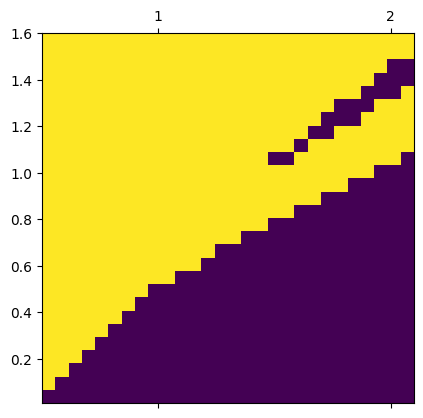

In [7]:
grad_g = phases_vfield(rdms, scale=1)
ys = np.sin(np.angle(grad_g) + theta)

# Labels plot
plt.matshow(np.sign(ys), origin='lower', extent=params_extent)

In [8]:
rdms = rdms[1:-1, 1:-1] # TODO fix

In [9]:
lattice_shape = rdms.shape[:2]
rdms = np.reshape(rdms, (-1, ) + rdms.shape[2:])
ys = ys.flatten()

In [10]:
# Old code based on eigendecomposition.

#assert rdms.ndim == 3


#def mats_to_vv_sum(mats):
#    mats = np.asarray(mats)
#    # Vectorize each matrix (row-major)
#    mats = np.reshape(mats, (len(mats), -1))
#    # vec(rho)vec(rho)^H
#    mats = np.einsum('ia, ib -> iab', mats, np.conj(mats))
#    return np.sum(mats, axis=0)


# Normalization factors.
#fp, fn = 1 / np.count_nonzero(ys > 0), 1 / np.count_nonzero(ys < 0)
# Note we square the cardinality of the sets.
#fp, fn = fp ** 2, fn ** 2

# Tradeoff parameter.
# gamma = 10

#pos_y_term = -fp * mats_to_vv_sum(rdms[np.nonzero(ys > 0)])
#neg_y_term = fn * mats_to_vv_sum(rdms[np.nonzero(ys < 0)])
#if gamma is None:
#    gamma = -np.trace(pos_y_term)/np.trace(neg_y_term)
#m = pos_y_term + gamma * neg_y_term
# Check that matrix m is numerically close to Hermitian.
#assert np.allclose(m - m.conj(m).T, 0)

#m_eigval, m_eigvec = np.linalg.eigh(m)
# Eigenvector selection, default 0.
# m_ev_idx = 0     # Use value greater than 0 for sub-optimal but interesting solutions (eg floating phase).
# Observable is taken as the eigenvector (reshaped to matrix) corresponding to the least eigenvalue (when eigvidx = 0,
# if there is multiplicity for now we ignore it) as it becomes 0 when the matrix m is shifted by -I * lambda_min (solution of the dual problem).
#obs = np.reshape(m_eigvec[:, m_ev_idx:(m_ev_idx + 1)], rdms[0].shape)

# TODO *** Consider multi dimensional eigenspaces ***.

# Check the observable is numerically close to Hermitian.
#assert np.allclose(obs - np.conj(obs).T, 0)

In [11]:
# New method

rhoa = rdms[np.nonzero(ys > 0)]
rhob = rdms[np.nonzero(ys < 0)]
rhoa = np.average(rhoa, axis=0)
rhob = np.average(rhob, axis=0)

rhoa = rhoa / np.linalg.norm(rhoa)
rhob = rhob / np.linalg.norm(rhob)

dot_ab = np.trace(rhoa * rhob)
obs = rhoa - dot_ab * rhob
obs = obs / np.sqrt(1 - dot_ab ** 2)

In [12]:
# Sanity-check. 0Check that candidate observables not numerically close to Hermitian
# correspond to eigenvalues numerically close to 0.

#for i in range(len(m_eigvec)):
#    test_obs = np.reshape(m_eigvec[:, i:(i + 1)], rdms[0].shape)
#    if not np.allclose(test_obs - np.conj(test_obs).T, 0):
#        assert np.isclose(m_eigval[i], 0)

In [13]:
# TODO Sanity-check on the presence of positive and negative eigenvalues not numerically close to 0.
# Note these are not the eigenvalues of the observable.
#m_eigval

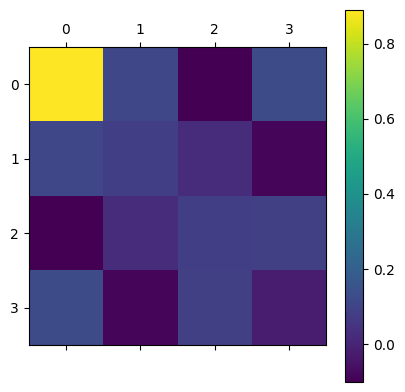

In [14]:
plt.matshow(obs.real)
plt.colorbar()

In [15]:
obs_eval, obs_ev = np.linalg.eigh(obs)
# Eigenvalues of the observable, check here the magnitudes (check also the sign!) and explore the specific projectors
# by setting the variable obs_ev_idx with the index of the selected eigenvector.
obs_eval

array([-0.1457782 ,  0.10440827,  0.1446045 ,  0.9268144 ])

In [16]:
SparsePauliOp.from_operator(obs)

SparsePauliOp(['II', 'IX', 'IZ', 'XI', 'XX', 'XZ', 'YY', 'ZI', 'ZX', 'ZZ'],
              coeffs=[ 0.25751224+2.08926181e-20j,  0.09935351-2.74103851e-20j,
  0.22804254-2.72606582e-21j, -0.09280716+2.02425519e-20j,
  0.07386404-2.02394822e-20j, -0.00790081+1.71330057e-21j,
 -0.05074826+1.00230679e-21j,  0.22803949-5.80593520e-21j,
  0.0107536 +1.17467364e-21j,  0.17606915-3.33842440e-21j])

In [17]:
operators = SparsePauliOp.from_operator(obs)
sorted_indices = np.argsort(operators.coeffs)[::-1]
components = operators.paulis
sorted_components = [components[i] for i in sorted_indices]

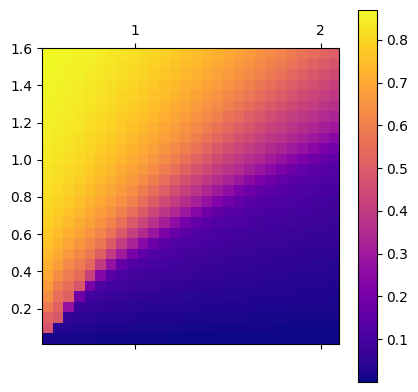

In [18]:
meas = [np.trace(rdm @ obs) for rdm in rdms]
meas = np.reshape(meas, lattice_shape)

# Note we plot the **absolute value**. The ordered phase can assume any non-zero value (positive and negative).
# So, we identify the disordered phase with the values close to 0 (numerically).
plt.matshow(np.abs(meas), origin='lower', cmap='plasma', extent=params_extent)
plt.colorbar()

In [19]:
# TODO Operator-Schmidt decomposition of obs to reveal if we are numerically close to product operator
# (useful for the floating phase).

In [20]:
# ************************************************************
# *** Analysis of a selected eigenvector of the observable ***
# ************************************************************
# Key parameters: obs_ev_idx (eigenvector index) and v0_first_schmidt_vec.

In [86]:
def make_obs_vec(obs_ev, obs_ev_idx):
    v0 = obs_ev[:, obs_ev_idx]

    # Schmidt coefficients w.r.t. middle split
    if v0_first_schmidt_vec:
        v0 = schmidt_decomp_half(v0, contract_sigmas=1, normalize=True)

    v0 = np.reshape(v0, (-1, 1))
    obs0 = np.sign(obs_eval[obs_ev_idx]) * v0 @ np.conj(v0.T)
    return obs0

def get_obs_ev(obs):
    obs_eval, obs_ev = np.linalg.eigh(obs)
    return obs_ev

def decompose_obs(obs):
    operators = SparsePauliOp.from_operator(obs)
    sorted_indices = np.argsort(operators.coeffs)[::-1]
    components = operators.paulis
    sorted_components = [components[i] for i in sorted_indices]
    return sorted_components[:4]

def plot_observable(obs, component=None):
    meas = [np.trace(rdm @ obs) for rdm in rdms]
    meas = np.reshape(meas, lattice_shape)

    # Note we plot the absolute value to avoid misunderstanding in the interpretation of the
    # colormap.
    fig, ax = plt.subplots(1,2, figsize=(10,4.5))
    ax0 = ax[0].matshow(np.abs(meas), origin='lower', cmap='plasma', aspect='auto', extent=params_extent)
    fig.colorbar(ax0, ax=ax[0])
    ax[0].set_xlabel('$\\kappa$')
    ax[0].set_ylabel('h')
    if component is None:
        title_str = "Whole Observable"
        figure_name = f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_{len(sites)}-rdm_OPD.png"
    else:
        title_str = f"Eigvec: {component}"
        figure_name = f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_{len(sites)}-rdm_OPD_component_{component}.png"
    ax[0].set_title(title_str)

    sorted_components = decompose_obs(obs)
    ax1 = ax[1].matshow(obs.real, aspect='auto')
    fig.colorbar(ax1, ax=ax[1])
    ax[1].set_xticks([0,1,2,3], sorted_components)
    ax[1].set_yticks([0,1,2,3], sorted_components)
    ax[1].set_title("Pauli Decomposition")
    plt.tight_layout()

    plt.savefig(figure_name)
    plt.show()

def plot_four_components(obs):
    obs_ev = get_obs_ev(obs)
    for obs_ev_idx in range(4):
        obs_vec = make_obs_vec(obs_ev, obs_ev_idx)
        plot_observable(obs_vec, component=obs_ev_idx)

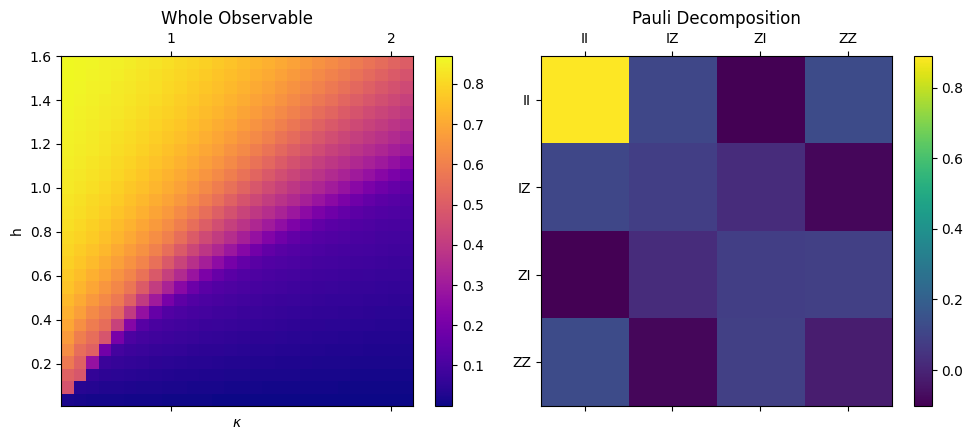

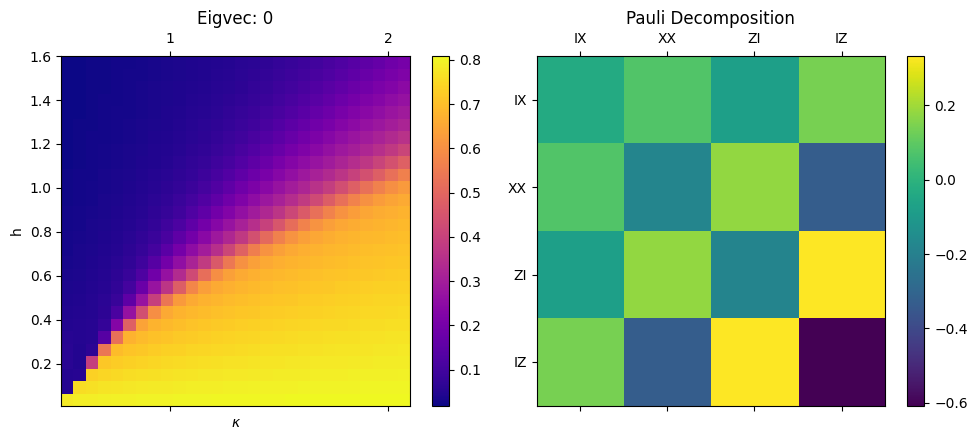

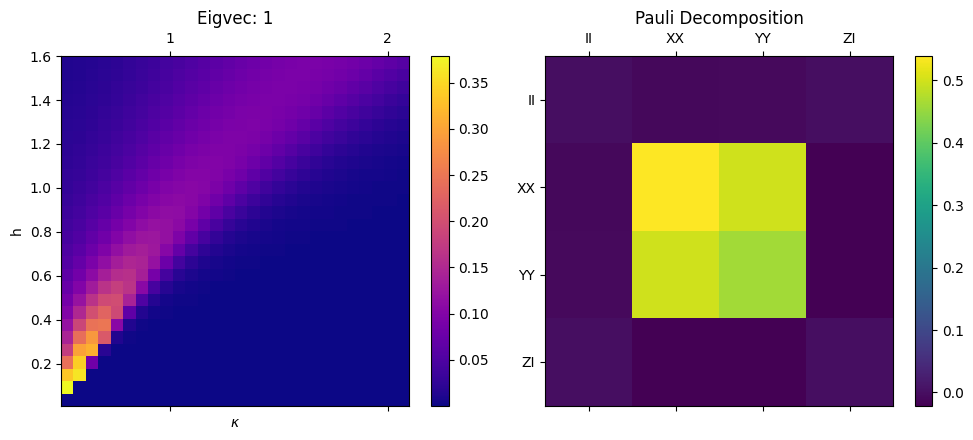

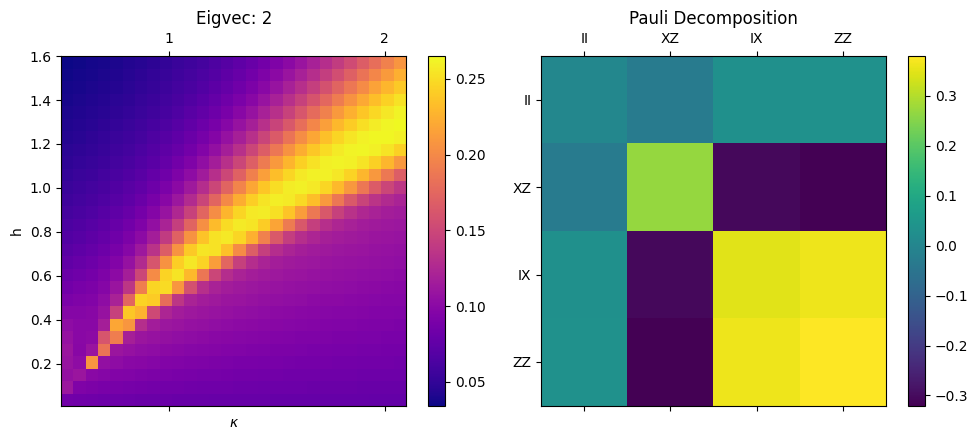

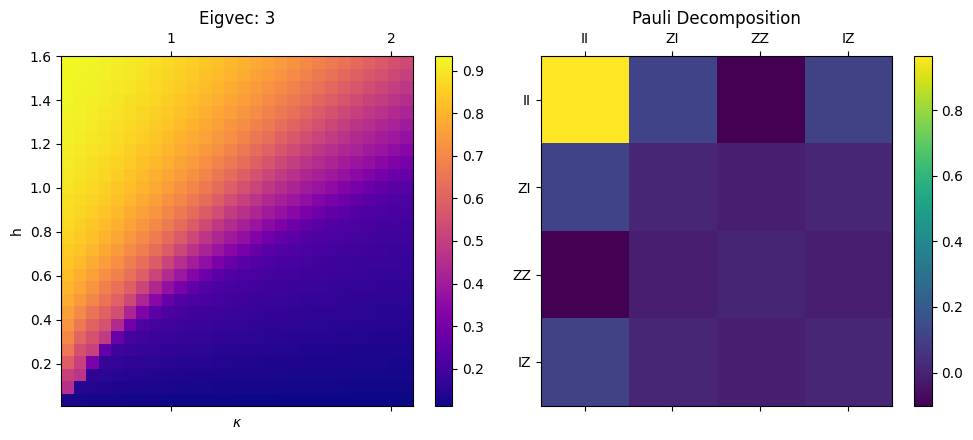

(None, None)

In [87]:
plot_observable(obs), plot_four_components(obs)

In [ ]:
# Select a rank-1 observable (note the ordering of the eigenvalues of obs).
obs_ev_idx = 2

v0 = obs_ev[:, obs_ev_idx]

# Schmidt coefficients w.r.t. middle split
v0_schmidt_coeffs = schmidt_decomp_half(v0)[1]
v0_schmidt_coeffs

In [ ]:
# Angles for each qubit in the decomposition of v0 (assumed 2 qubits state).
schmidt_decomp_2q_angles(v0)[0]

In [ ]:
schmidt_decomp_2q_angles(v0)[0] / np.pi

In [ ]:
# Optionally take first component of Schmidt decomp.
# v0_first_schmidt_vec = True

if v0_first_schmidt_vec:
    v0 = schmidt_decomp_half(v0, contract_sigmas=1, normalize=True)

v0 = np.reshape(v0, (-1, 1))
obs0 = np.sign(obs_eval[obs_ev_idx]) * v0 @ np.conj(v0.T)

SparsePauliOp.from_operator(obs0)

In [ ]:
plt.matshow(obs0.real)
plt.colorbar()

In [ ]:
obs0

In [ ]:
meas = [np.trace(rdm @ obs0) for rdm in rdms]
meas = np.reshape(meas, lattice_shape)

# Note we plot the absolute value to avoid misunderstanding in the interpretation of the
# colormap.
plt.matshow(np.abs(meas), origin='lower', cmap='plasma', extent=params_extent)
plt.xlabel('$\\kappa$')
plt.ylabel('h')
plt.colorbar()

In [ ]:
plot_grad_g_angle_stream(grad_g, params_extent=params_extent, theory_lines=False);